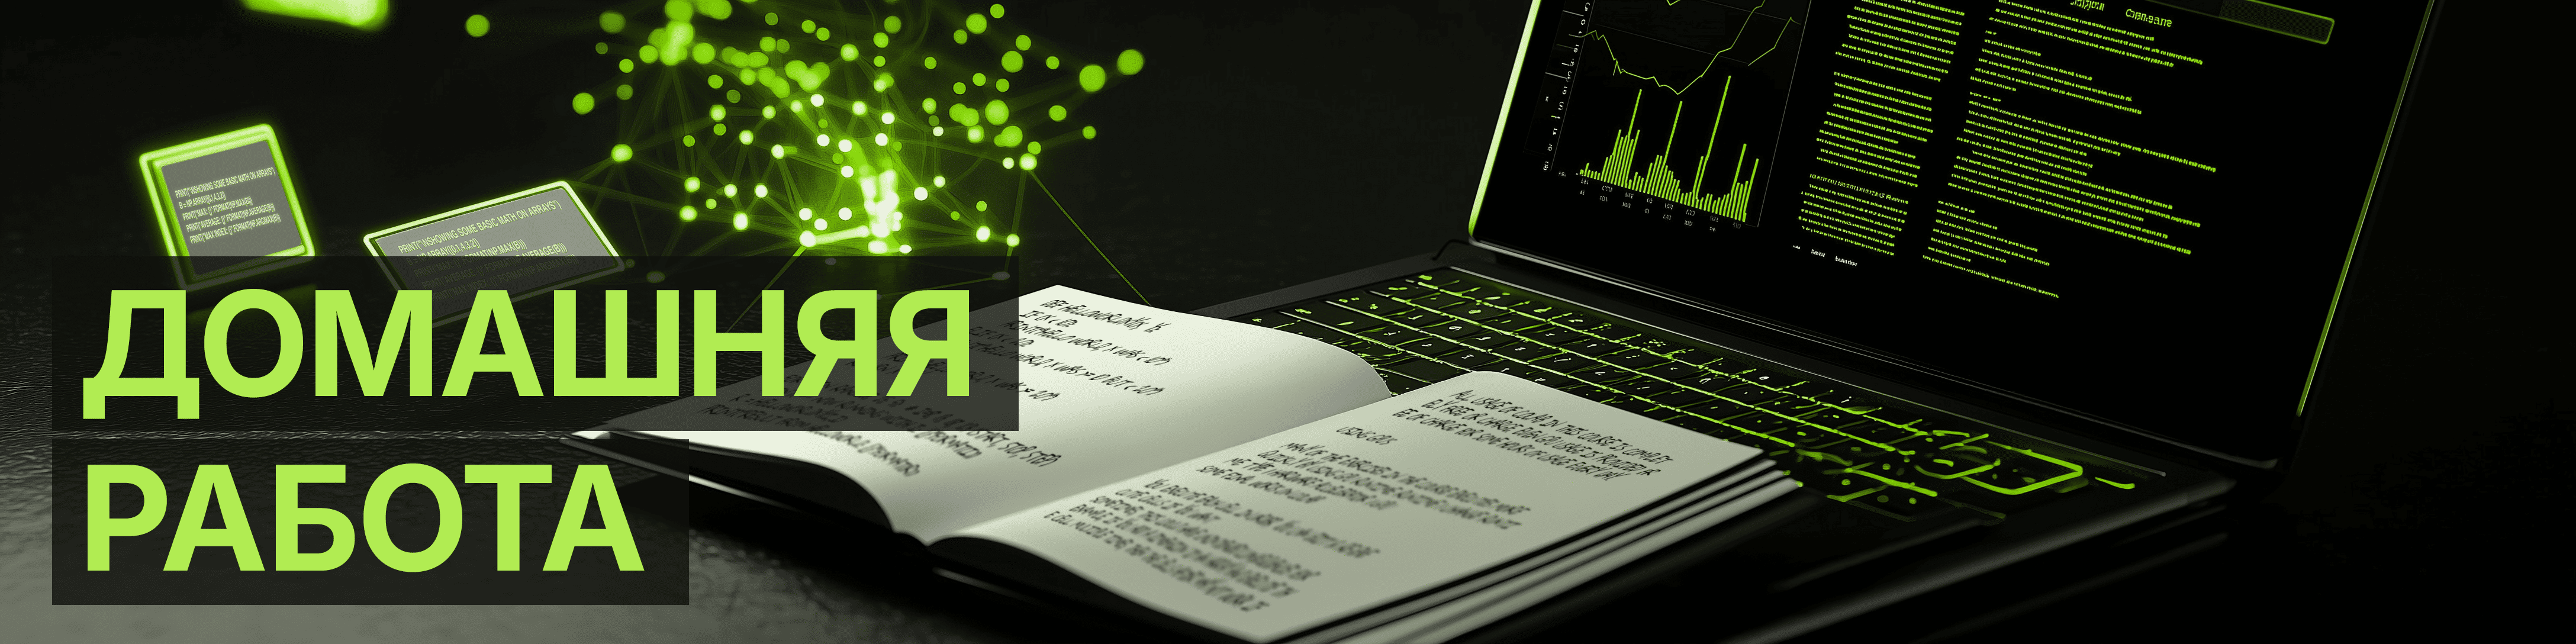

**Навигация по уроку**

1. [Задачи машинного зрения на OpenCV](https://colab.research.google.com/drive/1x1rxbNfV1ft1ztIPwxA3q34J4MULix5A)
2. [OpenCV. Распознавание лиц (практика)](https://colab.research.google.com/drive/1GwMZ8BAjtdKBDA5S0lAX1OPMFmIaYhqL)
3. Домашняя работа


Используя знания из практической части урока и функцию `blur_face` (размытие), проведите следующий эксперимент:
1. Найдите фото любого известного актера или актрисы.
2. Распознайте лицо на фотографии. Выделите лицо овалом. Какой метод для рисования овала использовать, вы должны найти самостоятельно.
3. Выделите на изображении глаза. Выделите их кружком. Если вы чувствуете в себе суперсилу и дополнительный бекграунд знаний, и хотите получить больше баллов за задание, то нарисуйте вместо кружков солнцезащитные очки (картинку очков можно найти в интернете, задача их правильно масштабировать и разместить).
4. Все лицо кроме глаз необходимо "заблюрить" (размыть) с помощью функции `blur_face` (функция объявлена ниже).




Оценка за задание:
* 1 балл - задача решена с помощью куратора, лицо распознано прямоугольником, глаза кругом.
* 2 балла - задача решена с незначительными подсказками куратора, лицо распознано прямоугольником или кругом, глаза кругом, лицо размыто.
* 3 балла - задача решена самостоятельно, лицо распознано овалом, глаза кругом, удалось заблюрить лицо, не затронув глаза.
* 4 балла - задача решена самостоятельно на 3 балла, удалось нарисовать очки с подсказкой куратора, недостаточна соблюдена симметрия расположения очков или недостаточно учтены их размеры.
* 5 баллов - задача полностью решена самостоятельно, все пункты выполнены.

In [ ]:
import cv2

def blur_face(img):
  (h, w) = img.shape[:2]
  dW = int(w / 3.0)
  dH = int(h / 3.0)
  if dW % 2 == 0:
      dW -= 1
  if dH % 2 == 0:
      dH -= 1
  return cv2.GaussianBlur(img, (dW, dH), 0)



In [1]:
import cv2
import gdown
from matplotlib import pyplot
# Команда обеспечивает вывод графиков в Google Colaboratory
%matplotlib inline

gdown.download('https://storage.yandexcloud.net/ai-2025/square_320_708e7f8d1ea1ab486c0c939dc79bba8b.jpg', None, quiet=True)

# Загрузка изображения
img = cv2.imread('./square_320_708e7f8d1ea1ab486c0c939dc79bba8b.jpg')

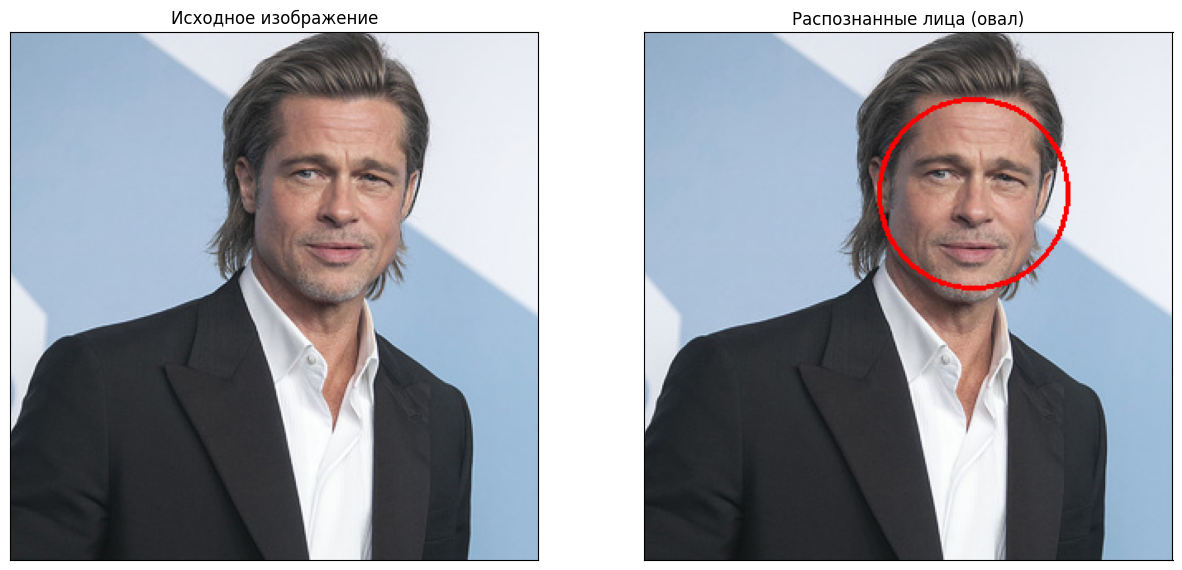

In [4]:
# Просто присвоить значение мы не можем, так как произойдет просто присваивание по ссылке
# т.е. обе переменые будут ссылаться на одну и ту же область памяти
# изменение одной переменной привет к изменению другой
img2 = img.copy() # копирование переменной


# загрузка каскада Хаара
classifier = cv2.CascadeClassifier(cv2.data.haarcascades+ "haarcascade_frontalface_default.xml")

# выполнение распознавания лиц
bboxes = classifier.detectMultiScale(img)

# Формирование овала вокруг каждого обнаруженного лица
for box in bboxes:
    # Формирование координат
    x, y, width, height = box
    center = (x + width // 2, y + height // 2)  # Центр овала
    axes = (width // 2, height // 2)  # Полуоси овала

    # Рисование овала
    cv2.ellipse(img2, center, axes, 0, 0, 360, (0, 0, 255), 2)




fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(15, 8))
ax1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax1.xaxis.set_ticks([])
ax1.yaxis.set_ticks([])
ax1.set_title('Исходное изображение')

ax2.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
ax2.xaxis.set_ticks([])
ax2.yaxis.set_ticks([])
ax2.set_title('Распознанные лица (овал)')

pyplot.show()

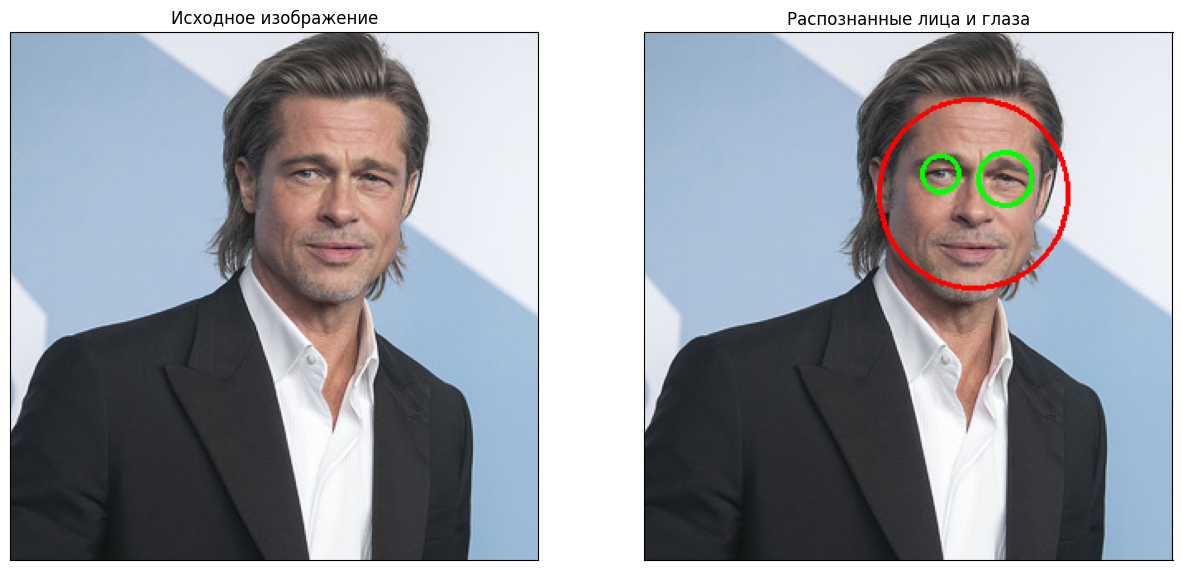

In [7]:
import cv2
import gdown
from matplotlib import pyplot as plt

# Команда обеспечивает вывод графиков в Google Colaboratory
%matplotlib inline

# Загрузка изображения
gdown.download('https://storage.yandexcloud.net/ai-2025/square_320_708e7f8d1ea1ab486c0c939dc79bba8b.jpg', None, quiet=True)
img = cv2.imread('./square_320_708e7f8d1ea1ab486c0c939dc79bba8b.jpg')
img2 = img.copy()

# загрузка каскада Хаара для поиска лиц
classifier_face = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

# загрузка каскада Хаара для поиска глаз
classifier_eye = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

# выполнение распознавания лиц
bboxes = classifier_face.detectMultiScale(img, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

# формирование овала вокруг каждого обнаруженного лица
for box in bboxes:
    # формирование координат
    x, y, width, height = box
    center = (x + width // 2, y + height // 2)  # Центр овала
    axes = (width // 2, height // 2)  # Оси овала (половина ширины и высоты)

    # рисование овала вокруг лица
    cv2.ellipse(img2, center, axes, 0, 0, 360, (0, 0, 255), 2)

    face = img[y:y + height, x:x + width]  # найденная область с лицом

    # выполнение распознавания глаз
    eyes = classifier_eye.detectMultiScale(face)

    for (x_eye, y_eye, w_eye, h_eye) in eyes:
        # определяем центр овала для глаз
        center = (int(x + x_eye + 0.5 * w_eye), int(y + y_eye + 0.5 * h_eye))
        axes_eye = (w_eye // 2, h_eye // 2)  # Оси овала для глаза

        # рисуем овал для глаз
        cv2.ellipse(img2, center, axes_eye, 0, 0, 360, (0, 255, 0), 2)

# Отображение изображений
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))
ax1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax1.xaxis.set_ticks([])
ax1.yaxis.set_ticks([])
ax1.set_title('Исходное изображение')

ax2.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
ax2.xaxis.set_ticks([])
ax2.yaxis.set_ticks([])
ax2.set_title('Распознанные лица и глаза')

plt.show()

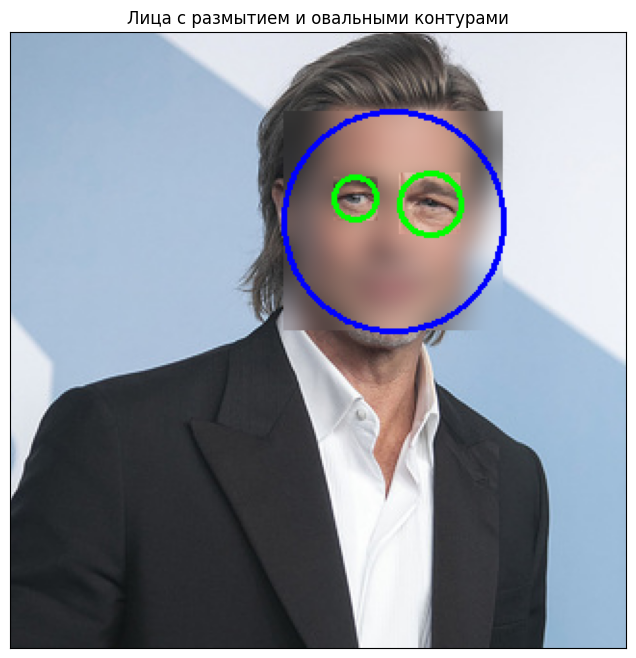

In [9]:
import cv2
import gdown
from matplotlib import pyplot as plt

# Команда для вывода графиков в Google Colaboratory
%matplotlib inline

def blur_face(img):
    (h, w) = img.shape[:2]
    dW = int(w / 3.0)
    dH = int(h / 3.0)
    if dW % 2 == 0:
        dW -= 1
    if dH % 2 == 0:
        dH -= 1
    return cv2.GaussianBlur(img, (dW, dH), 0)

# Загрузка изображения
gdown.download('https://storage.yandexcloud.net/ai-2025/square_320_708e7f8d1ea1ab486c0c939dc79bba8b.jpg', None, quiet=True)
img = cv2.imread('./square_320_708e7f8d1ea1ab486c0c939dc79bba8b.jpg')
img2 = img.copy()

# Загрузка каскада Хаара для поиска лиц и глаз
classifier_face = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
classifier_eye = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

# Выполнение распознавания лиц
bboxes = classifier_face.detectMultiScale(img, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

# Обрабатываем каждое найденное лицо
for box in bboxes:
    # Формирование координат
    x, y, width, height = box
    face_region = img[y:y + height, x:x + width]  # Найденная область с лицом

    # Размываем лицо
    blurred_face = blur_face(face_region)

    # Заменяем размытую область лица на размытое изображение
    img2[y:y + height, x:x + width] = blurred_face

    # Выполнение распознавания глаз
    eyes = classifier_eye.detectMultiScale(face_region)

    for (x_eye, y_eye, w_eye, h_eye) in eyes:
        # Копируем глаза из оригинального изображения
        eye_region = img[y + y_eye:y + y_eye + h_eye, x + x_eye:x + x_eye + w_eye]

        # Вставляем глаза в размытую область лица
        img2[y + y_eye:y + y_eye + h_eye, x + x_eye:x + x_eye + w_eye] = eye_region

        # Рисуем овал для глаз на итоговом изображении
        center = (int(x + x_eye + 0.5 * w_eye), int(y + y_eye + 0.5 * h_eye))
        axes_eye = (w_eye // 2, h_eye // 2)  # Оси овала для глаза
        cv2.ellipse(img2, center, axes_eye, 0, 0, 360, (0, 255, 0), 2)  # Зеленый овал для глаз

    # Рисуем овал для лица на итоговом изображении
    center_face = (int(x + width / 2), int(y + height / 2))
    axes_face = (width // 2, height // 2)  # Оси овала для лица
    cv2.ellipse(img2, center_face, axes_face, 0, 0, 360, (255, 0, 0), 2)  # Красный овал для лица

# Отображение изображений
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
ax.xaxis.set_ticks([])
ax.yaxis.set_ticks([])
ax.set_title('Лица с размытием и овальными контурами')

# Сохранение итогового изображения
cv2.imwrite('output_blurred_faces_with_ovals.jpg', img2)

plt.show()